# Feature Engineering: Long Snapshots -> Per-Video Lifecycle Features

**UGDSAI 29 · Group 4 · Aaryan, Daksh, Mayank**

This notebook implements Anant's directive: cluster at the **video level** using lifecycle-derived features, not at the (video, timestamp) level.

**Input:** `data/master_snapshots.csv` (long format, one row per snapshot observation)
**Output:** `data/videos_features.csv` (wide format, one row per unique video, 25+ engineered features)

**Feature themes (matching Anant's note):**
1. Velocity — how fast it grew
2. Decay — how fast it died
3. Retention — sticky vs flash
4. Engagement — audience response
5. Content & metadata — what the video itself is

The actual feature engineering logic lives in `scripts/features.py` so it can be unit-tested and re-used. This notebook is a thin walkthrough that calls into it.

## Switching from synthetic to real data

Change `INPUT_CSV` below to `'../data/master_snapshots.csv'` once collection has produced enough rows. Everything else just works.

In [1]:
import sys; sys.path.insert(0, '../scripts')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from features import build_features

pd.set_option('display.max_columns', 60)

# === SWITCH HERE WHEN REAL DATA IS READY ===
INPUT_CSV = '../data/master_snapshots_synthetic.csv'   # synthetic for dev
# INPUT_CSV = '../data/master_snapshots.csv'           # real data
OUTPUT_CSV = '../data/videos_features.csv'

## 1. Load and understand the raw data

In [2]:
df = pd.read_csv(INPUT_CSV)
print(f'Rows: {len(df):,}')
print(f'Unique videos: {df["video_id"].nunique():,}')
print(f'Snapshots: {df["snapshot_ts"].nunique()}')
df.head(3)

Rows: 976
Unique videos: 340
Snapshots: 20


,snapshot_ts,snapshot_ts_ist,trending_rank,video_id,title,channel_id,channel_title,channel_subscriber_count,category_id,published_at,duration_iso,view_count,like_count,comment_count,tags,description_length,default_audio_language,default_language,made_for_kids,definition,caption,licensed_content,thumbnail_url,_true_archetype,_title_caps_ratio_seed,_has_emoji_seed
0,2026-05-02T04:30:00+00:00,2026-05-02T10:00:00+05:30,1,UvAm7MDqb65,You Wont Believe - explained in 10 minutes,UCW1FG9J-ck_TMNIUS4sofR6,Channel_megaphone_6387,406961,24,2026-05-01T10:51:15+00:00,PT2M45S,3640609,41692,3577,follow|you wont believe|india|trending|indian|...,2827,en,en,False,hd,False,False,https://i.ytimg.com/vi/UvAm7MDqb65/hqdefault.jpg,megaphone,0.288880,False
1,2026-05-02T04:30:00+00:00,2026-05-02T10:00:00+05:30,2,92QlV8lHl9K,Like review 2026,UCiyz98KAmwNL4M0LVYUpuJE,Channel_megaphone_6551,592985,10,2026-05-02T01:24:26+00:00,PT5M50S,3525428,16907,841,must watch|omg|subscribe|viral|shocking|shorts...,90,en,en,False,hd,False,False,https://i.ytimg.com/vi/92QlV8lHl9K/hqdefault.jpg,megaphone,0.493667,False
2,2026-05-02T04:30:00+00:00,2026-05-02T10:00:00+05:30,3,jA6bmZeGbxm,Support review 2026,UCaCROfFgBwCdiqepuCqT9Ux,Channel_megaphone_1591,723041,22,2026-05-01T05:08:50+00:00,PT4M49S,3299018,33579,1784,share|shorts|support|fyp|comment|wow|best|omg|...,1671,hi,hi,False,hd,False,False,https://i.ytimg.com/vi/jA6bmZeGbxm/hqdefault.jpg,megaphone,0.498146,False


In [3]:
obs_per_video = df.groupby('video_id').size()
print('Observations per video:')
print(obs_per_video.describe().round(2))
print()
print('Videos seen N times:')
print(obs_per_video.value_counts().sort_index())

Observations per video:
count    340.00
mean       2.87
std        1.48
min        1.00
25%        2.00
50%        3.00
75%        4.00
max        8.00
dtype: float64

Videos seen N times:
1    74
2    76
3    81
4    59
5    33
6    14
7     2
8     1
Name: count, dtype: int64


**Decision:** keep videos with **>= 2 snapshots** so velocity/decay are computable. Videos seen only once go to a singletons file for completeness but don't enter the clustering matrix.

## 2. Run feature engineering

The work is encapsulated in `scripts/features.py` — `build_features()` takes the long-format DataFrame and returns the wide per-video matrix. This separates the *logic* (the script, version-controlled and testable) from the *narrative* (this notebook).

In [4]:
features = build_features(df, min_obs=2)
print(f'Feature matrix: {features.shape[0]} videos x {features.shape[1]} features')
print()
print('Missing values per column (top 10):')
print(features.isna().sum().sort_values(ascending=False).head(10))

Feature matrix: 266 videos x 27 features

Missing values per column (top 10):
half_life_hours           77
decay_log_slope_48h        2
peak_views_per_hour        0
hours_to_first_trend       0
mean_views_per_hour        0
days_observed_on_chart     0
chart_presence_ratio       0
rank_volatility            0
returned_count             0
mean_like_view_ratio       0
dtype: int64


## 3. Inspect the 5 themes

Group features by what they measure. This grouping is exactly how we'll explain them to the panel.

In [5]:
themes = {
    'Velocity':   ['peak_views_per_hour', 'mean_views_per_hour', 'hours_to_first_trend'],
    'Decay':      ['decay_log_slope_48h', 'half_life_hours', 'days_observed_on_chart'],
    'Retention':  ['chart_presence_ratio', 'rank_volatility', 'returned_count'],
    'Engagement': ['mean_like_view_ratio', 'mean_comment_view_ratio',
                   'comment_like_ratio', 'engagement_growth'],
    'Content':    ['duration_seconds', 'is_short', 'title_length', 'title_caps_ratio',
                   'title_has_emoji', 'title_has_question', 'tag_count',
                   'mean_tag_length', 'description_length',
                   'category_id', 'channel_subs', 'channel_size_bucket', 'language'],
}
for theme, cols in themes.items():
    cols_present = [c for c in cols if c in features.columns]
    print(f'  {theme:11s} ({len(cols_present)} features): {cols_present}')

  Velocity    (3 features): ['peak_views_per_hour', 'mean_views_per_hour', 'hours_to_first_trend']
  Decay       (3 features): ['decay_log_slope_48h', 'half_life_hours', 'days_observed_on_chart']
  Retention   (3 features): ['chart_presence_ratio', 'rank_volatility', 'returned_count']
  Engagement  (4 features): ['mean_like_view_ratio', 'mean_comment_view_ratio', 'comment_like_ratio', 'engagement_growth']
  Content     (13 features): ['duration_seconds', 'is_short', 'title_length', 'title_caps_ratio', 'title_has_emoji', 'title_has_question', 'tag_count', 'mean_tag_length', 'description_length', 'category_id', 'channel_subs', 'channel_size_bucket', 'language']


## 4. Sanity check — feature distributions

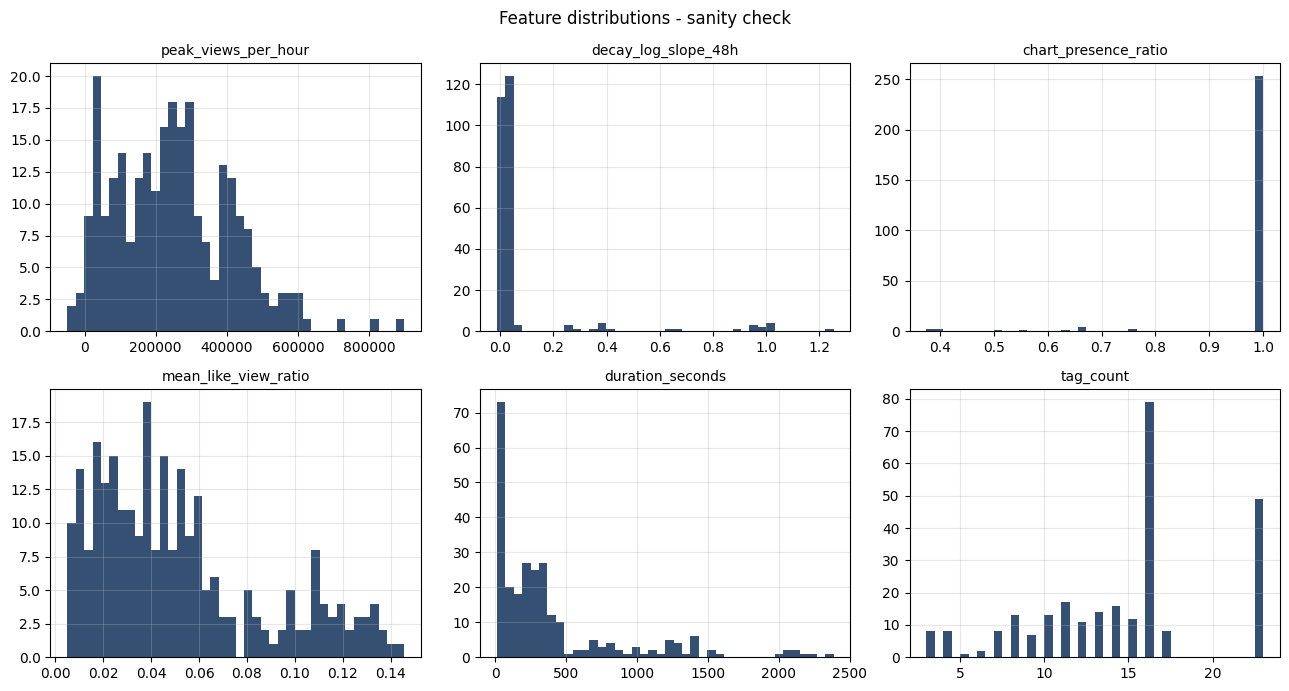

In [6]:
key_features = [
    'peak_views_per_hour', 'decay_log_slope_48h', 'chart_presence_ratio',
    'mean_like_view_ratio', 'duration_seconds', 'tag_count',
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, key_features):
    features[col].dropna().hist(bins=40, ax=ax, color='#13315C', alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.grid(alpha=0.3)
fig.suptitle('Feature distributions - sanity check', fontsize=12)
fig.tight_layout(); plt.show()

## 5. Save and we're done

In [7]:
features.to_csv(OUTPUT_CSV)
print(f'Saved -> {OUTPUT_CSV}')
print(f'Shape: {features.shape}')
features.head()

Saved -> ../data/videos_features.csv
Shape: (266, 27)


,peak_views_per_hour,mean_views_per_hour,hours_to_first_trend,decay_log_slope_48h,half_life_hours,days_observed_on_chart,chart_presence_ratio,rank_volatility,returned_count,mean_like_view_ratio,mean_comment_view_ratio,comment_like_ratio,engagement_growth,duration_seconds,is_short,title_length,title_caps_ratio,title_has_emoji,title_has_question,tag_count,mean_tag_length,description_length,category_id,channel_subs,channel_size_bucket,language,_true_archetype
video_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
UvAm7MDqb65,415311.083333,282812.300000,17.645833,0.023983,12.0,3,1.0,3.619392,0,0.011862,0.000909,0.077150,0.000944,165,0,42,0.093750,0,0,23,6.478261,2827,24,406961,mid,en,megaphone
92QlV8lHl9K,340498.916667,259420.645833,3.092778,0.030142,24.0,3,1.0,4.000000,0,0.005055,0.000235,0.048014,0.000261,350,0,16,0.100000,0,0,23,6.478261,90,10,592985,mid,en,megaphone
jA6bmZeGbxm,455750.500000,336788.500000,23.352778,0.037358,12.0,3,1.0,3.563706,0,0.010696,0.000569,0.047039,0.000825,289,0,19,0.076923,0,0,23,6.521739,1671,22,723041,mid,hi,megaphone
IzWsMIAEB4_,421995.166667,312790.125000,18.356667,0.050052,12.0,2,1.0,1.732051,0,0.007426,0.001024,0.130336,0.000028,147,0,15,0.071429,0,0,23,6.434783,2976,24,988625,mid,hi,megaphone
la1SRlgINct,424103.333333,265717.066667,16.411944,0.025691,12.0,3,1.0,3.687818,0,0.016030,0.000592,0.042062,-0.001461,212,0,23,0.210526,0,0,23,6.478261,2369,22,497426,mid,hi,megaphone
